In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load your dataset
df = pd.read_csv('matches.csv')
df.info()
df["season"].unique()
df["player_of_match"]
df[df["city"] == "mumbai"]
df.head()
df.tail()
df[df["winner"] == "Chennai Super Kings"]
df.isnull().sum()
len(df)
df.fillna("unknown")
df.shape
print(df.shape)              
print(df.dtypes)
print(df.describe())
print(df.describe(include='object'))
print(df.nunique())
df.head(10)
print(df.isnull().sum())
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))
df_clean = df.dropna()
print(df_clean)
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))
df_clean = df.dropna()
print(df_clean)
# Option 2: Fill numeric columns with median
# Verify — should show 0s now
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates: {len(df)}")
df['date'] = pd.to_datetime(df['date'])









<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

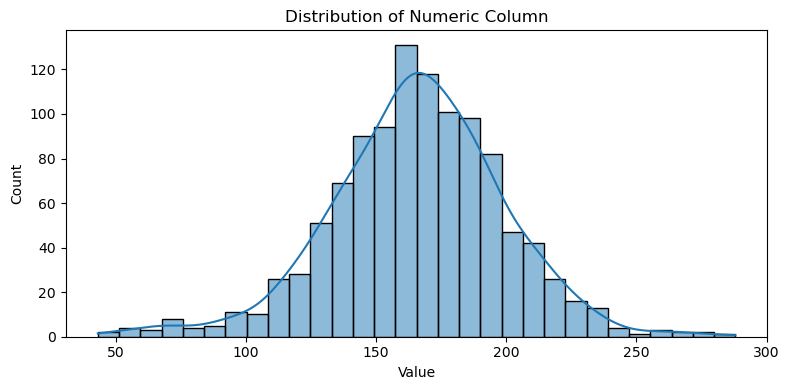

In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(df['target_runs'], bins=30, kde=True)
plt.title('Distribution of Numeric Column')
plt.xlabel('Value')
plt.tight_layout()
plt.show()

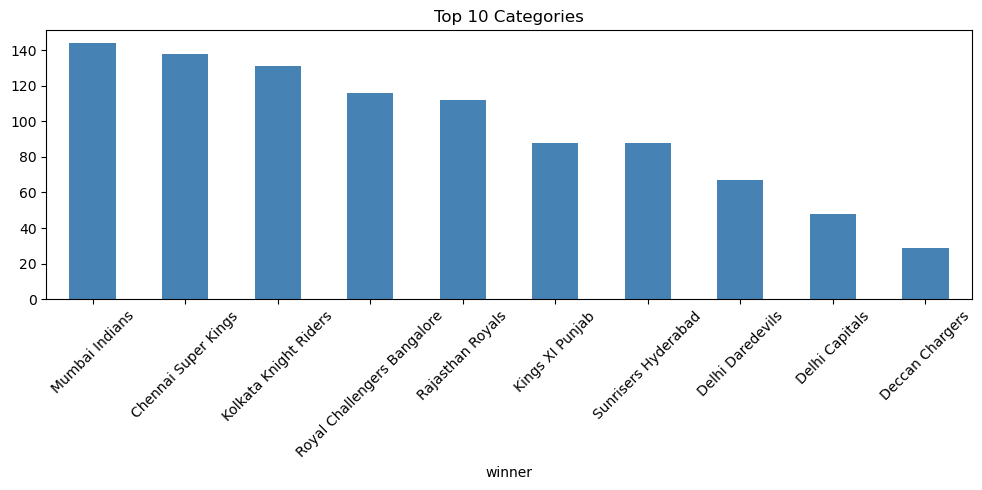

In [15]:
plt.figure(figsize=(10, 5))
df['winner'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

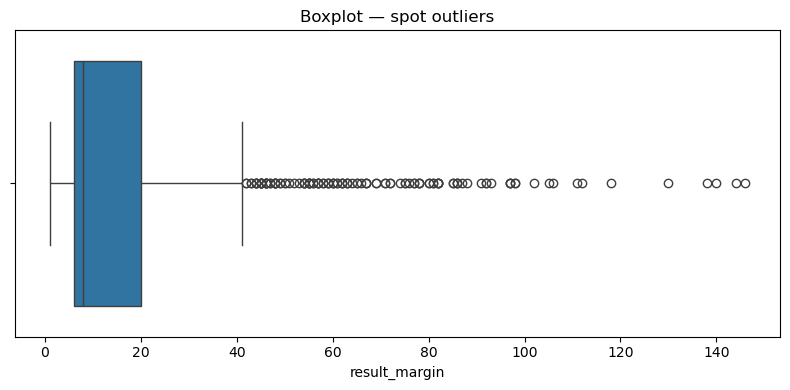

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['result_margin'])
plt.title('Boxplot — spot outliers')
plt.tight_layout()
plt.show()

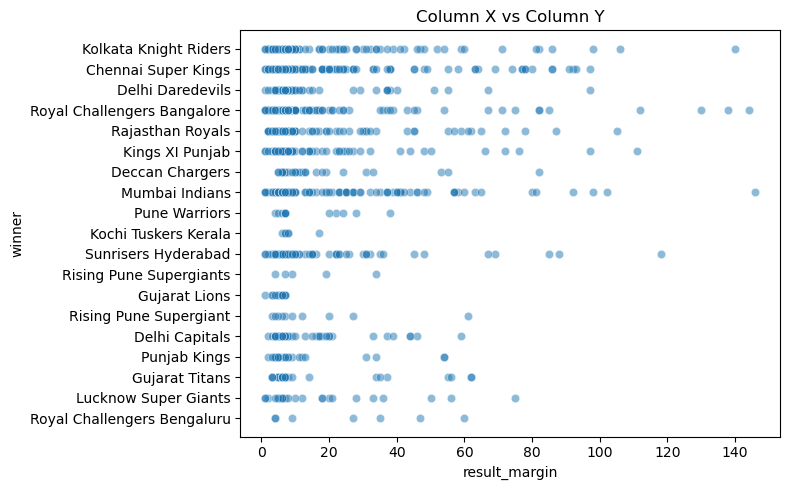

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='result_margin', y='winner', alpha=0.5)
plt.title('Column X vs Column Y')
plt.tight_layout()
plt.show()

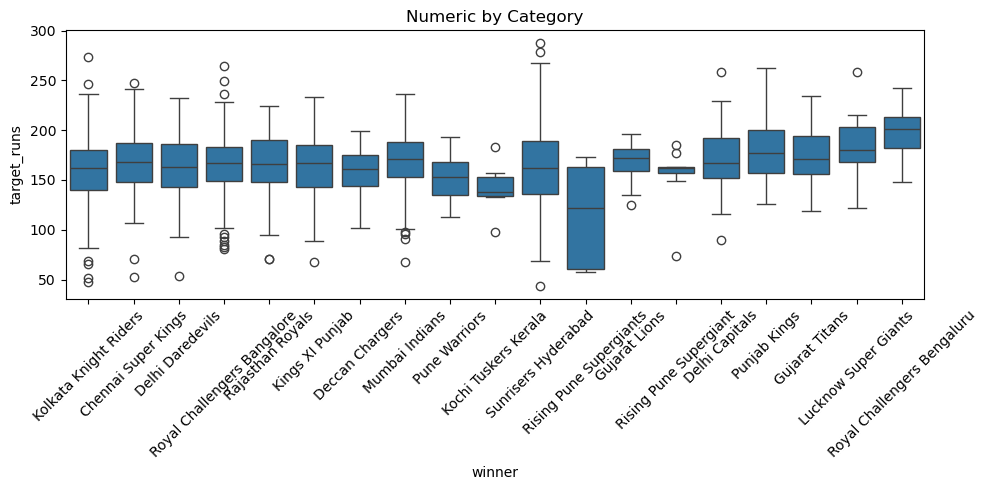

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='winner', y='target_runs')
plt.title('Numeric by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\vardhan2003\AppData\Local\Temp\ipykernel_9104\2977184081.py:4: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


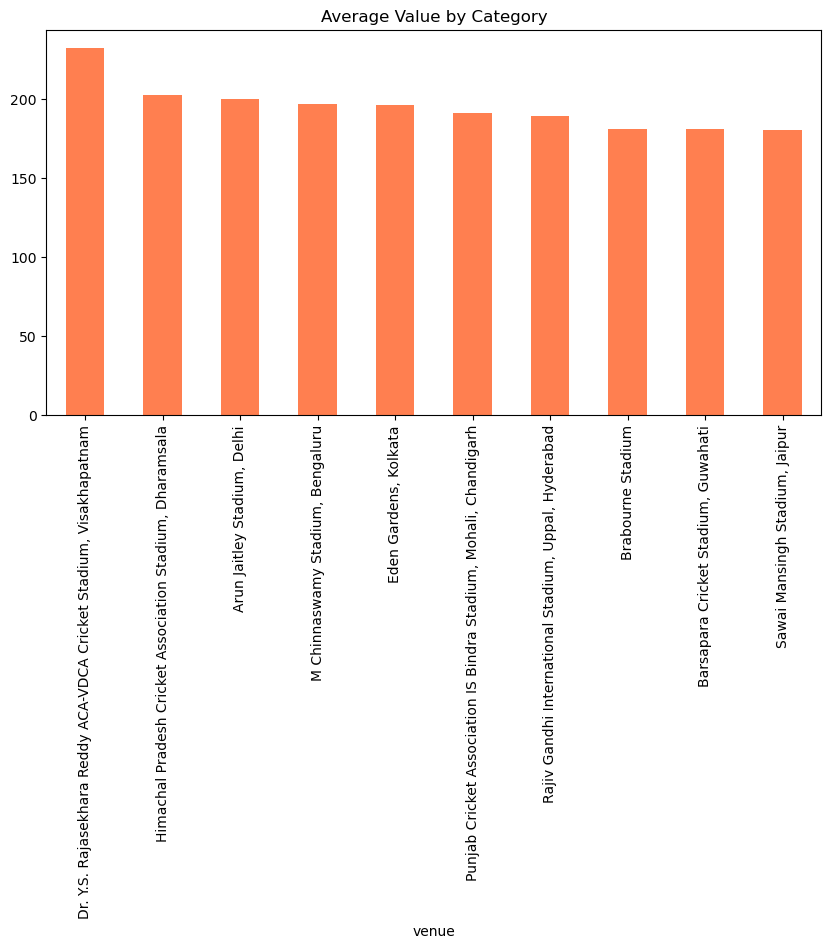

In [26]:
avg_by_cat = df.groupby('venue')['target_runs'].mean().sort_values(ascending=False)
avg_by_cat.head(10).plot(kind='bar', figsize=(10, 5), color='coral')
plt.title('Average Value by Category')
plt.tight_layout()
plt.show()

In [27]:
numeric_df = df.select_dtypes(include=[np.number])

In [29]:
# Compute correlation matrix
corr_matrix = numeric_df.corr()

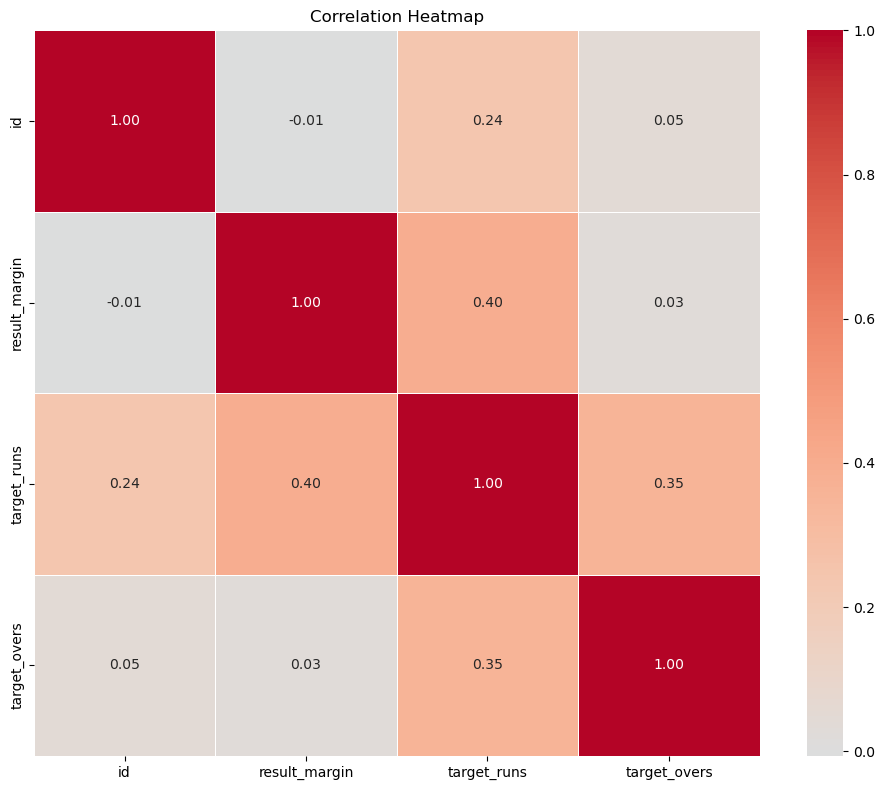

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # show numbers in cells
    fmt='.2f',         # 2 decimal places
    cmap='coolwarm',   # red = positive, blue = negative
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [31]:
# Print strongest correlations (above 0.5 or below -0.5)
strong = corr_matrix.abs().unstack().sort_values(ascending=False)
print(strong[strong < 1].head(10))

result_margin  target_runs      0.395120
target_runs    result_margin    0.395120
               target_overs     0.352361
target_overs   target_runs      0.352361
id             target_runs      0.238859
target_runs    id               0.238859
id             target_overs     0.046388
target_overs   id               0.046388
result_margin  target_overs     0.030970
target_overs   result_margin    0.030970
dtype: float64


In [34]:
# Make sure date column is datetime typ
df['date'] = pd.to_datetime(df['date'])

In [37]:
# Group by year and count/sum
yearly = df.groupby('season')['player_of_match'].sum().reset_index()

In [ ]:
'''
## Key Findings

1. **Winning the Toss Doesn't Always Guarantee Victory**: Teams winning the toss do not consistently win the match, indicating that overall team performance has a greater impact than the toss outcome.

2. **Home Teams Have a Slight Advantage**: Teams playing at their home venues show a higher win percentage, suggesting that familiarity with pitch conditions and crowd support contribute to better performance.

3. **Top Batters and Bowlers Dominate Across Seasons**: A small group of players consistently ranks among the highest run scorers and wicket takers, highlighting their long-term impact on IPL success.

4. **Certain Venues Produce High-Scoring Matches**: Stadiums such as batting-friendly venues record significantly higher average first-innings scores compared to others.

5. **Teams Batting First Tend to Win More Often at Some Grounds**: Match outcomes vary by venue, with several stadiums favoring teams setting a target.

## Recommendations

- Prioritize player retention for consistently high-performing batters and bowlers.
- Develop venue-specific strategies based on historical match outcomes.
- Consider pitch conditions rather than relying solely on the toss while making match decisions.
- Use historical venue data for team selection and batting order planning.
- Focus performance analysis on opposition-specific and venue-specific trends.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook
'''